In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OrdinalEncoder


In [2]:
# Cargamos datos
df = pd.read_csv("../data/car.data.csv", header=None)

df.columns, df.head(), df.shape

(Index([0, 1, 2, 3, 4, 5, 6], dtype='int64'),
        0      1  2  3      4     5      6
 0  vhigh  vhigh  2  2  small   low  unacc
 1  vhigh  vhigh  2  2  small   med  unacc
 2  vhigh  vhigh  2  2  small  high  unacc
 3  vhigh  vhigh  2  2    med   low  unacc
 4  vhigh  vhigh  2  2    med   med  unacc,
 (1728, 7))

In [3]:
# Añadimos los nombres a las columnas
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [4]:
# Comprobamos nulos, tipos y cantidad de cada target
df.info()
df.isna().sum()
df['class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [5]:
df['class'].value_counts(normalize=True)

class
unacc    0.700231
acc      0.222222
good     0.039931
vgood    0.037616
Name: proportion, dtype: float64

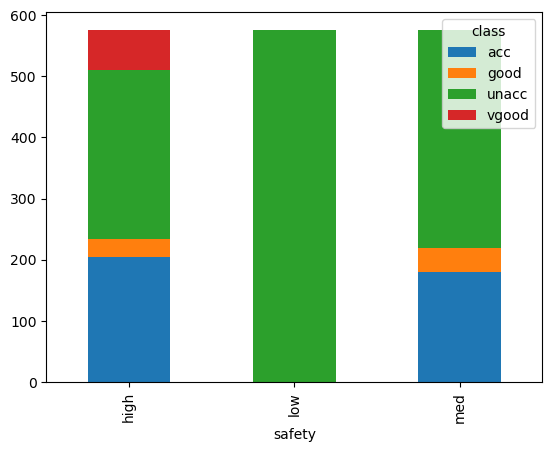

In [6]:
pd.crosstab(df['safety'], df['class']).plot(kind='bar', stacked=True)
plt.show()

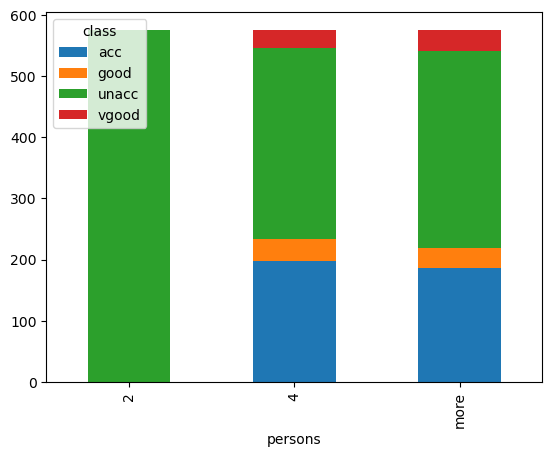

In [7]:
pd.crosstab(df['persons'], df['class']).plot(kind='bar', stacked=True)
plt.show()

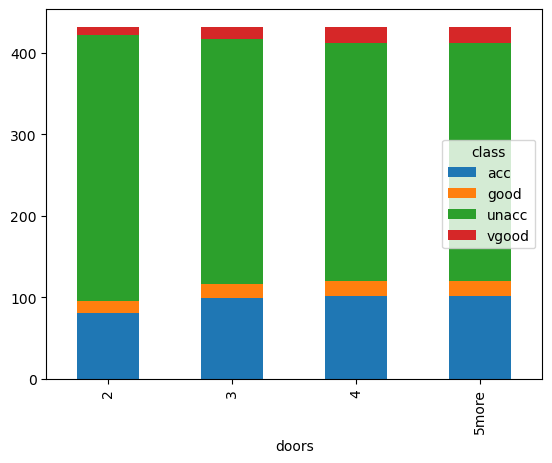

In [8]:
pd.crosstab(df['doors'], df['class']).plot(kind='bar', stacked=True)
plt.show()

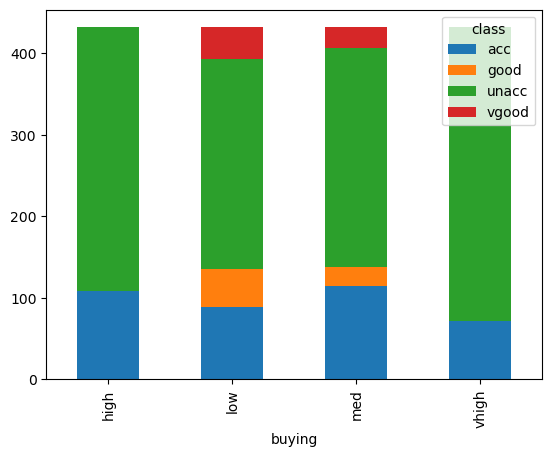

In [9]:
pd.crosstab(df['buying'], df['class']).plot(kind='bar', stacked=True)
plt.show()

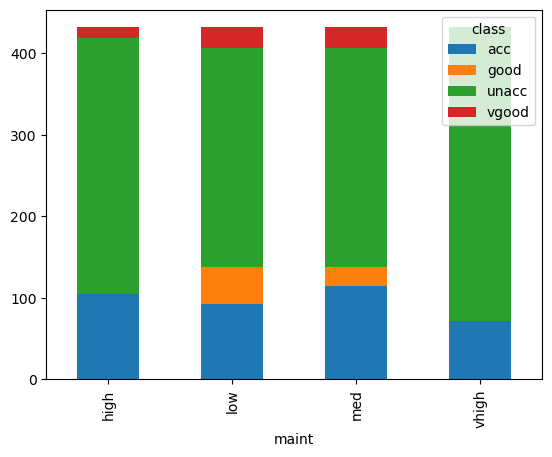

In [10]:
pd.crosstab(df['maint'], df['class']).plot(kind='bar', stacked=True)
plt.show()

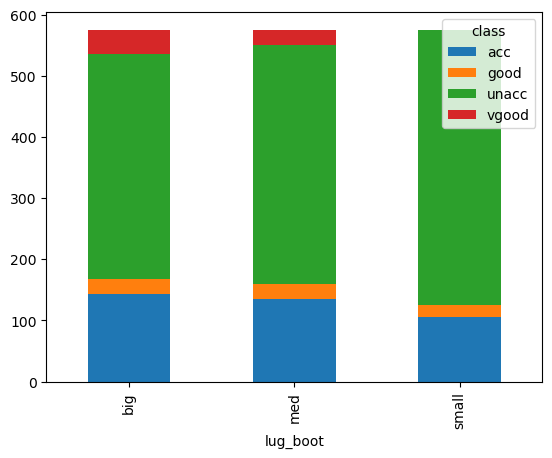

In [11]:
pd.crosstab(df['lug_boot'], df['class']).plot(kind='bar', stacked=True)
plt.show()

In [12]:
# Separamos X/y
X = df.drop(columns='class')
y = df['class']

In [13]:
# Encoding
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns=X.columns)
X_encoded.head()

,buying,maint,doors,persons,lug_boot,safety
0,3.0,3.0,0.0,0.0,2.0,1.0
1,3.0,3.0,0.0,0.0,2.0,2.0
2,3.0,3.0,0.0,0.0,2.0,0.0
3,3.0,3.0,0.0,0.0,1.0,1.0
4,3.0,3.0,0.0,0.0,1.0,2.0


In [14]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)

In [15]:
# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9046242774566474
              precision    recall  f1-score   support

         acc       0.88      0.76      0.82        79
        good       0.80      0.47      0.59        17
       unacc       0.92      0.99      0.95       240
       vgood       0.88      0.70      0.78        10

    accuracy                           0.90       346
   macro avg       0.87      0.73      0.78       346
weighted avg       0.90      0.90      0.90       346



In [17]:
# Comparamos con otros valores de k

k_values = [3, 5, 7, 9]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    print(f"k = {k} --> accuracy = {score:.3f}")

k = 3 --> accuracy = 0.829
k = 5 --> accuracy = 0.905
k = 7 --> accuracy = 0.931
k = 9 --> accuracy = 0.902


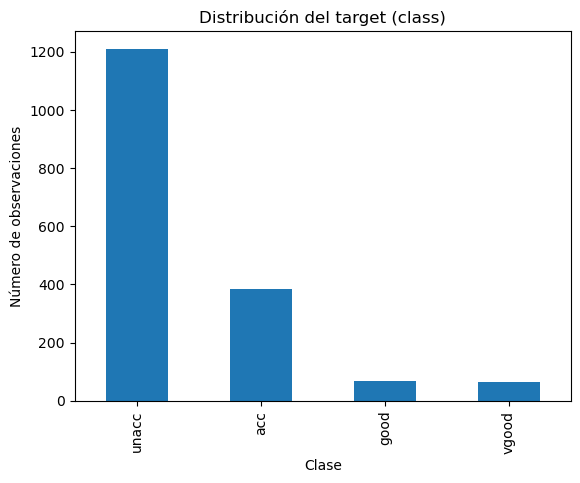

In [18]:
class_counts = df['class'].value_counts()
class_counts.plot(kind="bar")
plt.title("Distribución del target (class)")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.show()

**Conclusión Día 1**:
Se ha construido un modelo baseline de clasificación usando KNN después de aplicar encoding ordinal a las variables categóricas. 
En los siguientes dias lo compararemos con otros modelos.
- k = 3 --> accuracy = 0.829
- k = 5 --> accuracy = 0.905
- k = 7 --> accuracy = 0.931
- k = 9 --> accuracy = 0.902

Se ha decidido no aplicar técnicas de balanceo, ya que el desbalance observado proviene de unas reglas estrictas generadas en el dataset original.